# yfinance Exploration

Exploratory notebook to understand what yfinance provides and whether it can improve signal quality.

The predictions from 2026-04-25 were poor. This notebook investigates:
1. What data yfinance exposes beyond OHLCV
2. Data quality vs existing Polygon data
3. Which fields could add genuine signal (fundamentals, analyst ratings, options flow, earnings surprises)
4. Whether yfinance is viable as a free, no-key-required data source

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Fixed universe from configs/ingestion.yaml
UNIVERSE = [
    'ILLR', 'PAPL', 'BMNR', 'GPUS', 'SMCI',
    'BMNU', 'NVTS', 'ELPW', 'LNAI', 'INTC',
    'TSLL', 'TLRY', 'OPEN', 'NVDA', 'BMNG',
]

In [3]:
TICKER = 'NVDA'   # change this to explore any ticker
tk = yf.Ticker(TICKER)
print(f'yfinance {yf.__version__} — exploring {TICKER}')

yfinance 1.3.0 — exploring NVDA


## 1. What attributes does a Ticker object expose?

In [4]:
# Every data category yfinance can return
categories = [
    ('info',                    'Company metadata, sector, market cap, P/E, 52-week range, analyst targets'),
    ('fast_info',               'Lightweight version — price, volume, market cap only'),
    ('history',                 'OHLCV + dividends + stock splits (daily/weekly/monthly)'),
    ('actions',                 'Dividends and splits history'),
    ('dividends',               'Dividend history'),
    ('splits',                  'Stock split history'),
    ('financials',              'Annual income statement'),
    ('quarterly_financials',    'Quarterly income statement'),
    ('balance_sheet',           'Annual balance sheet'),
    ('quarterly_balance_sheet', 'Quarterly balance sheet'),
    ('cashflow',                'Annual cash flow statement'),
    ('quarterly_cashflow',      'Quarterly cash flow statement'),
    ('earnings',                'Annual EPS + revenue'),
    ('quarterly_earnings',      'Quarterly EPS + revenue vs estimates'),
    ('recommendations',         'Analyst buy/hold/sell ratings history'),
    ('analyst_price_targets',   'Price targets from analysts (low/mean/high/current)'),
    ('earnings_dates',          'Next + past earnings dates'),
    ('earnings_estimate',       'EPS estimates by analysts'),
    ('revenue_estimate',        'Revenue estimates by analysts'),
    ('eps_trend',               'EPS estimate trend — how forecasts changed over time'),
    ('eps_revisions',           'Analyst upward/downward EPS revisions'),
    ('growth_estimates',        'EPS growth estimates — next quarter, next year'),
    ('upgrades_downgrades',     'Individual analyst rating changes'),
    ('institutional_holders',   'Top institutional holders + % of shares'),
    ('major_holders',           'Insider + institutional % breakdown'),
    ('insider_transactions',    'Recent insider buy/sell filings'),
    ('insider_purchases',       'Insider purchases summary'),
    ('options',                 'Available expiry dates for options chain'),
    ('news',                    'Recent news headlines from Yahoo Finance'),
    ('calendar',                'Upcoming earnings date + EPS/revenue estimates'),
]

print(f'{len(categories)} data categories available:\n')
for attr, desc in categories:
    print(f'  tk.{attr:<30} {desc}')

30 data categories available:

  tk.info                           Company metadata, sector, market cap, P/E, 52-week range, analyst targets
  tk.fast_info                      Lightweight version — price, volume, market cap only
  tk.history                        OHLCV + dividends + stock splits (daily/weekly/monthly)
  tk.actions                        Dividends and splits history
  tk.dividends                      Dividend history
  tk.splits                         Stock split history
  tk.financials                     Annual income statement
  tk.quarterly_financials           Quarterly income statement
  tk.balance_sheet                  Annual balance sheet
  tk.quarterly_balance_sheet        Quarterly balance sheet
  tk.cashflow                       Annual cash flow statement
  tk.quarterly_cashflow             Quarterly cash flow statement
  tk.earnings                       Annual EPS + revenue
  tk.quarterly_earnings             Quarterly EPS + revenue vs estimates
  tk.

## 2. OHLCV — compare quality with existing Polygon data

In [5]:
yf_hist = tk.history(period='2y', interval='1d', auto_adjust=True)
print(f'yfinance history: {len(yf_hist)} rows, {yf_hist.index[0].date()} → {yf_hist.index[-1].date()}')
display(yf_hist.tail(5))

# Compare with Polygon data on disk
polygon_path = Path('../data/raw/ohlcv') / TICKER
polygon_files = list(polygon_path.glob('*.csv')) if polygon_path.exists() else []
if polygon_files:
    poly_df = pd.read_csv(sorted(polygon_files)[-1], parse_dates=['date'])
    print(f'\nPolygon data: {len(poly_df)} rows, {poly_df["date"].min().date()} → {poly_df["date"].max().date()}')
    print(f'yfinance rows: {len(yf_hist)} | Polygon rows: {len(poly_df)} | diff: {len(yf_hist) - len(poly_df)}')
else:
    print(f'\nNo Polygon data on disk for {TICKER}')

yfinance history: 501 rows, 2024-04-25 → 2026-04-24


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-20 00:00:00-04:00,199.979996,202.169998,197.839996,202.059998,119381400,0.0,0.0
2026-04-21 00:00:00-04:00,202.130005,202.750000,199.000000,199.880005,107945300,0.0,0.0
2026-04-22 00:00:00-04:00,200.990005,202.500000,199.000000,202.500000,107501000,0.0,0.0
2026-04-23 00:00:00-04:00,202.460007,203.830002,197.220001,199.639999,113561800,0.0,0.0
2026-04-24 00:00:00-04:00,199.960007,210.949997,199.809998,208.270004,213780100,0.0,0.0



Polygon data: 501 rows, 2024-04-25 → 2026-04-24
yfinance rows: 501 | Polygon rows: 501 | diff: 0


## 3. Analyst recommendations — a real signal for short-term moves

In [6]:
recs = tk.recommendations
if recs is None or recs.empty:
    print(f'No recommendations available for {TICKER}')
else:
    print(f'{len(recs)} recommendation entries')
    display(recs.tail(10))

    # Distribution of recent recommendations (last 90 days)
    recent_recs = recs.tail(30)
    if 'To Grade' in recent_recs.columns:
        grade_counts = recent_recs['To Grade'].value_counts()
        fig, ax = plt.subplots(figsize=(8, 3))
        grade_counts.plot(kind='barh', ax=ax, color='#4C72B0', alpha=0.8)
        ax.set_title(f'{TICKER} — analyst grade distribution (last 30 entries)', fontweight='bold')
        plt.tight_layout()
        plt.show()

4 recommendation entries


,period,strongBuy,buy,hold,sell,strongSell
0,0m,9,47,2,1,0
1,-1m,9,48,2,1,0
2,-2m,12,48,2,1,0
3,-3m,12,48,3,1,0


## 4. Analyst price targets — where analysts think the price is going

In [ ]:
targets = tk.analyst_price_targets
current = tk.fast_info.last_price
print(f'Current price: ${current:.2f}')
print()
if targets is None or (hasattr(targets, 'empty') and targets.empty):
    print('No price targets available')
else:
    print('Analyst price targets:')
    print(targets)
    if hasattr(targets, 'get'):
        mean_target = targets.get('mean') or targets.get('Mean')
        if mean_target and current:
            upside = (mean_target - current) / current * 100
            print(f'\nMean target: ${mean_target:.2f} → implied upside: {upside:+.1f}%')

Current price: $208.27

Analyst price targets:
{'current': 208.26, 'high': 380.0, 'low': 140.0, 'mean': 268.6148, 'median': 265.0}

Mean target: $268.61 → implied upside: +29.0%


## 5. Earnings — surprises drive the biggest short-term moves

In [ ]:
# Upcoming earnings
cal = tk.calendar
print(f'Calendar / next earnings:')
print(cal)

print()

# Historical earnings vs estimates
q_earn = tk.quarterly_earnings
if q_earn is not None and not q_earn.empty:
    print(f'\nHistorical quarterly earnings (actual vs estimate):')
    display(q_earn)

    if 'Actual' in q_earn.columns and 'Estimate' in q_earn.columns:
        q_earn_clean = q_earn.dropna(subset=['Actual', 'Estimate'])
        q_earn_clean['Surprise'] = q_earn_clean['Actual'] - q_earn_clean['Estimate']
        q_earn_clean['Surprise%'] = q_earn_clean['Surprise'] / q_earn_clean['Estimate'].abs() * 100
        print(f'\nEarnings surprises:')
        display(q_earn_clean[['Actual', 'Estimate', 'Surprise%']].round(2))

Calendar / next earnings:
{'Dividend Date': datetime.date(2026, 4, 1), 'Ex-Dividend Date': datetime.date(2026, 3, 11), 'Earnings Date': [datetime.date(2026, 5, 20)], 'Earnings High': 1.99, 'Earnings Low': 1.69, 'Earnings Average': 1.77461, 'Revenue High': 85512000000, 'Revenue Low': 77896000000, 'Revenue Average': 78785307760}



/Users/gracebraz/code/grcbrz/out-of-office/.venv/lib/python3.12/site-packages/yfinance/scrapers/fundamentals.py:33: DeprecationWarning: 'Ticker.earnings' is deprecated as not available via API. Look for "Net Income" in Ticker.income_stmt.
  warnings.warn("'Ticker.earnings' is deprecated as not available via API. Look for \"Net Income\" in Ticker.income_stmt.", DeprecationWarning)


## 6. Key info fields — what metadata is useful as features?

In [9]:
info = tk.info

# Fields most relevant for a trading model
useful_fields = [
    # Valuation
    'trailingPE', 'forwardPE', 'priceToBook', 'enterpriseToEbitda',
    'pegRatio',
    # Analyst consensus
    'recommendationMean',   # 1=Strong Buy 5=Strong Sell
    'recommendationKey',    # 'buy', 'hold', 'sell'
    'numberOfAnalystOpinions',
    'targetMeanPrice', 'targetLowPrice', 'targetHighPrice',
    # Momentum / technical
    'fiftyTwoWeekLow', 'fiftyTwoWeekHigh',
    'fiftyDayAverage', 'twoHundredDayAverage',
    '52WeekChange',
    # Short interest
    'shortRatio',           # days to cover (high = potential short squeeze)
    'shortPercentOfFloat',
    # Liquidity / size
    'marketCap', 'averageVolume', 'averageVolume10days', 'floatShares',
    # Fundamentals
    'revenueGrowth', 'earningsGrowth', 'returnOnEquity', 'debtToEquity',
    'freeCashflow', 'operatingMargins',
]

rows = []
for field in useful_fields:
    val = info.get(field)
    rows.append({'field': field, 'value': val, 'available': val is not None})

field_df = pd.DataFrame(rows)
available = field_df[field_df['available']]
missing   = field_df[~field_df['available']]

print(f'{TICKER}: {len(available)}/{len(useful_fields)} useful fields available\n')
print('Available:')
display(available.set_index('field')[['value']])
print(f'\nMissing: {missing["field"].tolist()}')

NVDA: 28/28 useful fields available

Available:


,value
field,
trailingPE,42.58896
forwardPE,18.529821
priceToBook,32.178616
enterpriseToEbitda,37.603
pegRatio,0.74
recommendationMean,1.28814
recommendationKey,strong_buy
numberOfAnalystOpinions,56
targetMeanPrice,268.6148



Missing: []


## 7. Short interest — potential short squeeze indicator

In [10]:
info = tk.info
short_ratio = info.get('shortRatio')
short_pct   = info.get('shortPercentOfFloat')
float_shares = info.get('floatShares')

print(f'{TICKER} short interest:')
print(f'  Short ratio (days to cover): {short_ratio}')
print(f'  Short % of float:            {short_pct:.1%}' if short_pct else '  Short % of float: N/A')
print(f'  Float shares:                {float_shares:,.0f}' if float_shares else '  Float shares: N/A')

if short_ratio and short_ratio > 5:
    print(f'\n  >>> HIGH short ratio — potential squeeze candidate')
elif short_ratio:
    print(f'\n  Normal short ratio')

NVDA short interest:
  Short ratio (days to cover): 1.68
  Short % of float:            1.2%
  Float shares:                23,321,682,000

  Normal short ratio


## 8. Options — implied volatility and put/call ratio

In [ ]:
expiries = tk.options
print(f'{TICKER} options expiry dates available: {len(expiries)}')
if expiries:
    print(f'Next 5: {expiries[:5]}')
    # Fetch nearest expiry
    nearest = expiries[0]
    chain = tk.option_chain(nearest)
    calls = chain.calls
    puts  = chain.puts

    # Put/call ratio by open interest (bearish indicator if > 1)
    total_call_oi = calls['openInterest'].sum()
    total_put_oi  = puts['openInterest'].sum()
    pc_ratio = total_put_oi / total_call_oi if total_call_oi else float('nan')

    # Average implied volatility (ATM options most relevant)
    current_price = tk.fast_info.last_price
    atm_calls = calls[abs(calls['strike'] - current_price) < current_price * 0.05]
    avg_iv = atm_calls['impliedVolatility'].mean() if not atm_calls.empty else float('nan')

    print(f'\nExpiry: {nearest}')
    print(f'  Calls: {len(calls)} strikes, total OI: {total_call_oi:,.0f}')
    print(f'  Puts:  {len(puts)} strikes,  total OI: {total_put_oi:,.0f}')
    print(f'  Put/Call OI ratio: {pc_ratio:.2f}  (> 1 = bearish skew)')
    print(f'  ATM implied volatility: {avg_iv:.1%}')

    print(f'\nATM calls (±5% of ${current_price:.2f}):')
    display(atm_calls[['strike', 'lastPrice', 'bid', 'ask', 'openInterest', 'impliedVolatility']].head(8))

NVDA options expiry dates available: 25
Next 5: ('2026-04-27', '2026-04-29', '2026-05-01', '2026-05-04', '2026-05-06')

Expiry: 2026-04-27
  Calls: 41 strikes, total OI: 131,985
  Puts:  33 strikes,  total OI: 73,271
  Put/Call OI ratio: 0.56  (> 1 = bearish skew)
  ATM implied volatility: 6.6%

ATM calls (±5% of $208.27):


,strike,lastPrice,bid,ask,openInterest,impliedVolatility
20,200.0,8.50,0.0,0.0,4481,0.000010
21,202.5,6.21,0.0,0.0,6876,0.000010
22,205.0,4.15,0.0,0.0,7183,0.000010
23,207.5,2.49,0.0,0.0,6608,0.000010
24,210.0,1.32,0.0,0.0,27291,0.031260
25,212.5,0.65,0.0,0.0,16939,0.125009
26,215.0,0.29,0.0,0.0,20351,0.125009
27,217.5,0.14,0.0,0.0,5627,0.250007


## 9. Field coverage across the full universe — which fields are reliable?

Checking 13 fields across 15 tickers...



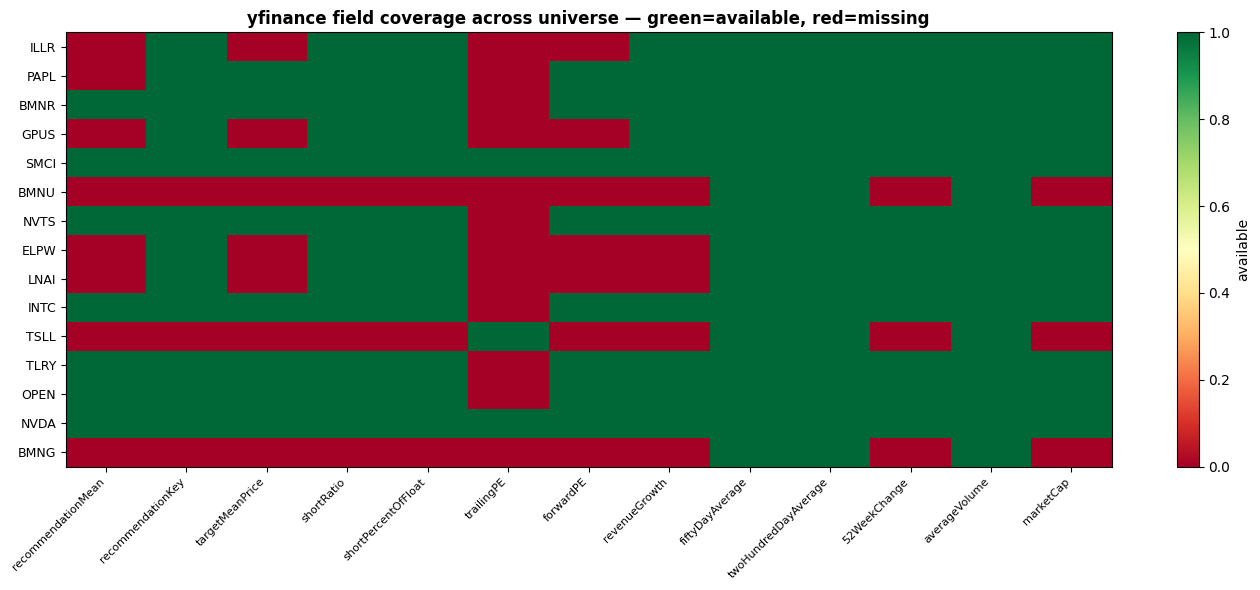


Field availability (% of tickers):
field
fiftyDayAverage         100
twoHundredDayAverage    100
averageVolume           100
recommendationKey        80
shortRatio               80
shortPercentOfFloat      80
52WeekChange             80
marketCap                80
revenueGrowth            67
targetMeanPrice          53
forwardPE                53
recommendationMean       47
trailingPE               20


In [12]:
CHECK_FIELDS = [
    'recommendationMean', 'recommendationKey', 'targetMeanPrice',
    'shortRatio', 'shortPercentOfFloat',
    'trailingPE', 'forwardPE', 'revenueGrowth',
    'fiftyDayAverage', 'twoHundredDayAverage', '52WeekChange',
    'averageVolume', 'marketCap',
]

print(f'Checking {len(CHECK_FIELDS)} fields across {len(UNIVERSE)} tickers...\n')

coverage = {}
for ticker in UNIVERSE:
    try:
        info = yf.Ticker(ticker).info
        coverage[ticker] = {f: (info.get(f) is not None) for f in CHECK_FIELDS}
    except Exception as e:
        coverage[ticker] = {f: False for f in CHECK_FIELDS}
        print(f'  {ticker}: error — {e}')

cov_df = pd.DataFrame(coverage).T
cov_df.columns.name = 'field'

# Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(cov_df.astype(int).values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(CHECK_FIELDS)))
ax.set_xticklabels(CHECK_FIELDS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(UNIVERSE)))
ax.set_yticklabels(UNIVERSE, fontsize=9)
ax.set_title('yfinance field coverage across universe — green=available, red=missing', fontweight='bold')
plt.colorbar(im, ax=ax, label='available')
plt.tight_layout()
plt.show()

print('\nField availability (% of tickers):')
print((cov_df.mean() * 100).round(0).astype(int).sort_values(ascending=False).to_string())

## 10. News headlines — compare with Alpha Vantage

In [13]:
import datetime

news = tk.news
if not news:
    print(f'No news available for {TICKER}')
else:
    rows = []
    for item in news:
        content = item.get('content', {})
        pub_ts = content.get('pubDate') or item.get('providerPublishTime')
        if isinstance(pub_ts, int):
            pub_dt = datetime.datetime.fromtimestamp(pub_ts)
        elif isinstance(pub_ts, str):
            try:
                pub_dt = datetime.datetime.fromisoformat(pub_ts.replace('Z', '+00:00'))
            except Exception:
                pub_dt = None
        else:
            pub_dt = None
        rows.append({
            'published': pub_dt,
            'title': (content.get('title') or item.get('title', ''))[:80],
            'source': content.get('provider', {}).get('displayName', '') if isinstance(content.get('provider'), dict) else item.get('publisher', ''),
        })
    news_df = pd.DataFrame(rows).sort_values('published', ascending=False)
    print(f'{len(news_df)} news items for {TICKER}:\n')
    display(news_df.head(10))

10 news items for NVDA:



,published,title,source
2,2026-04-27 11:07:00+00:00,"You Can Buy Stock in SpaceX, OpenAI, and Anthr...",Motley Fool
3,2026-04-27 10:55:00+00:00,1 Major Reason Why Broadcom Still Has More Roo...,Motley Fool
4,2026-04-27 10:31:00+00:00,Medicare Premiums Took Back Nearly a Third of ...,Motley Fool
5,2026-04-27 10:30:33+00:00,I Wish I Knew These 3 Things Before Buying My ...,24/7 Wall St.
6,2026-04-27 10:25:00+00:00,Warren Buffett vs. Bill Ackman: One Piled Into...,Motley Fool
7,2026-04-27 10:20:00+00:00,Nvidia vs. Netflix: Wall Street Says This Larg...,Motley Fool
8,2026-04-27 09:50:00+00:00,Intel Stock Is on a Tear. Why Its Earnings Pow...,Barrons.com
9,2026-04-27 09:31:00+00:00,Is SpaceX Really Worth $1.75 Trillion -- or Is...,Motley Fool
0,2026-04-26 14:30:00+00:00,'A return to optimism': Wall Street strategist...,Yahoo Finance
1,2026-04-26 11:30:16+00:00,Mag 7 earnings bonanza and Powell's home stret...,Yahoo Finance


## 11. Summary — what yfinance adds vs what the pipeline already has

In [14]:
summary = [
    ('OHLCV history',            'Polygon (current)',  'yfinance equivalent',   'yfinance is free/no key; Polygon has higher fidelity'),
    ('Sentiment score',          'Alpha Vantage',      '—',                     'AV scores are more structured; yf news has no score'),
    ('Analyst recommendations',  '—',                 'tk.recommendations',    'NEW — grade changes (Buy/Sell) are a known alpha signal'),
    ('Price targets',            '—',                 'tk.analyst_price_targets','NEW — mean/low/high targets; implied upside is a feature'),
    ('Earnings surprises',       '—',                 'tk.quarterly_earnings', 'NEW — post-earnings drift is one of the strongest effects'),
    ('Short interest',           '—',                 'tk.info[shortRatio]',   'NEW — squeeze setup indicator; updated bi-monthly'),
    ('Implied volatility',       '—',                 'tk.option_chain()',     'NEW — ATM IV reflects market uncertainty before events'),
    ('Put/call ratio',           '—',                 'tk.option_chain()',     'NEW — options positioning predicts near-term direction'),
    ('50/200-day MA',            'Computed (sma_20)',  'tk.info[fiftyDayAvg]', 'Redundant — already computed from OHLCV'),
    ('52-week range position',   '—',                 'tk.info[52WeekChange]', 'NEW — momentum signal'),
    ('Insider transactions',     '—',                 'tk.insider_transactions','NEW — insider buying is bullish; selling is weak signal'),
]

sum_df = pd.DataFrame(summary, columns=['Data type', 'Current source', 'yfinance source', 'Notes'])
display(sum_df)

print('\nHighest-signal additions (in order of likely impact on predictions):')
high_impact = [
    '1. Earnings surprises     — post-earnings drift is large and predictable (3–5 days)',
    '2. Analyst upgrade/downgrade changes — grade changes move price same day',
    '3. Put/call ratio + IV    — options market is forward-looking, prices in known events',
    '4. Short interest ratio   — high short ratio + positive catalyst = squeeze setup',
    '5. 52-week range position — momentum effect; near 52w high tends to keep going',
]
for item in high_impact:
    print(f'  {item}')

,Data type,Current source,yfinance source,Notes
0,OHLCV history,Polygon (current),yfinance equivalent,yfinance is free/no key; Polygon has higher fi...
1,Sentiment score,Alpha Vantage,—,AV scores are more structured; yf news has no ...
2,Analyst recommendations,—,tk.recommendations,NEW — grade changes (Buy/Sell) are a known alp...
3,Price targets,—,tk.analyst_price_targets,NEW — mean/low/high targets; implied upside is...
4,Earnings surprises,—,tk.quarterly_earnings,NEW — post-earnings drift is one of the strong...
5,Short interest,—,tk.info[shortRatio],NEW — squeeze setup indicator; updated bi-monthly
6,Implied volatility,—,tk.option_chain(),NEW — ATM IV reflects market uncertainty befor...
7,Put/call ratio,—,tk.option_chain(),NEW — options positioning predicts near-term d...
8,50/200-day MA,Computed (sma_20),tk.info[fiftyDayAvg],Redundant — already computed from OHLCV
9,52-week range position,—,tk.info[52WeekChange],NEW — momentum signal



Highest-signal additions (in order of likely impact on predictions):
  1. Earnings surprises     — post-earnings drift is large and predictable (3–5 days)
  2. Analyst upgrade/downgrade changes — grade changes move price same day
  3. Put/call ratio + IV    — options market is forward-looking, prices in known events
  4. Short interest ratio   — high short ratio + positive catalyst = squeeze setup
  5. 52-week range position — momentum effect; near 52w high tends to keep going
